<a href="https://colab.research.google.com/github/Saibot2012/long-exposure-fusion/blob/main/pw2_linearfiltering_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical work 2: Linear filtering

The goal of this first practical session is to understand and try out python functions for image processing, and to get acquainted with image processing libraries, especially scikit-image. We will first go over how to visualize an image and its histogram. Then, we will try to understand the frequential content of an image thanks to the two-dimensional Fourier transform. Finally we will try out different linear filterings of our images.

## Image loading and visualization

In order to load and display images, we will use basic functions of scikit-image, numpy, and matplotlib. You can either use our images, or images that are stored in your Google Drive.

To download our images, execute the following command :

In [1]:
#Dowmloading images
!wget https://perso.telecom-paristech.fr/aleclaire/athens/imagesTP1.zip
!unzip -qq imagesTP1.zip
!rm imagesTP1.zip

--2026-04-08 06:36:38--  https://perso.telecom-paristech.fr/aleclaire/athens/imagesTP1.zip
Resolving perso.telecom-paristech.fr (perso.telecom-paristech.fr)... 137.194.22.227, 2a04:8ec0:0:a::89c2:16e3
Connecting to perso.telecom-paristech.fr (perso.telecom-paristech.fr)|137.194.22.227|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5233563 (5.0M) [application/zip]
Saving to: ‘imagesTP1.zip’

imagesTP1.zip       100%[===================>]   4.99M  3.02MB/s    in 1.7s    

2026-04-08 06:36:41 (3.02 MB/s) - ‘imagesTP1.zip’ saved [5233563/5233563]



In [3]:
import matplotlib.pyplot as plt
import skimage.io as skio
import skimage
import numpy as np
import numpy.fft as fft

To visualize and load an image, you will use the function `plt.imread`.

rgb image shape : (1200, 1920, 3)


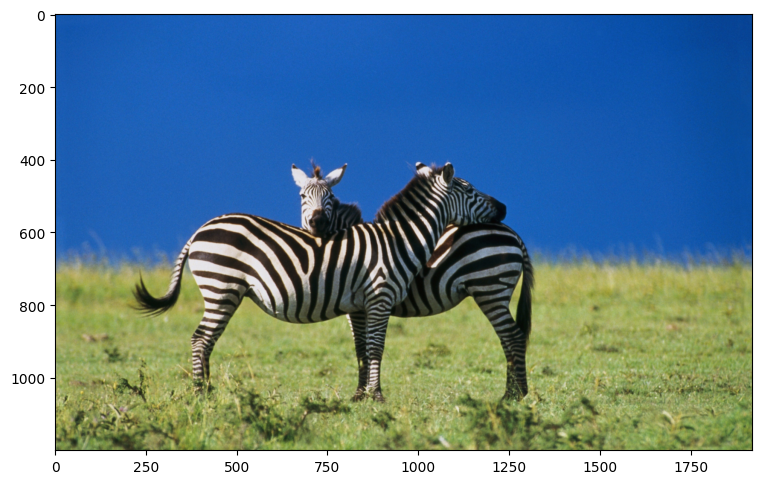

gray image shape : (512, 512)


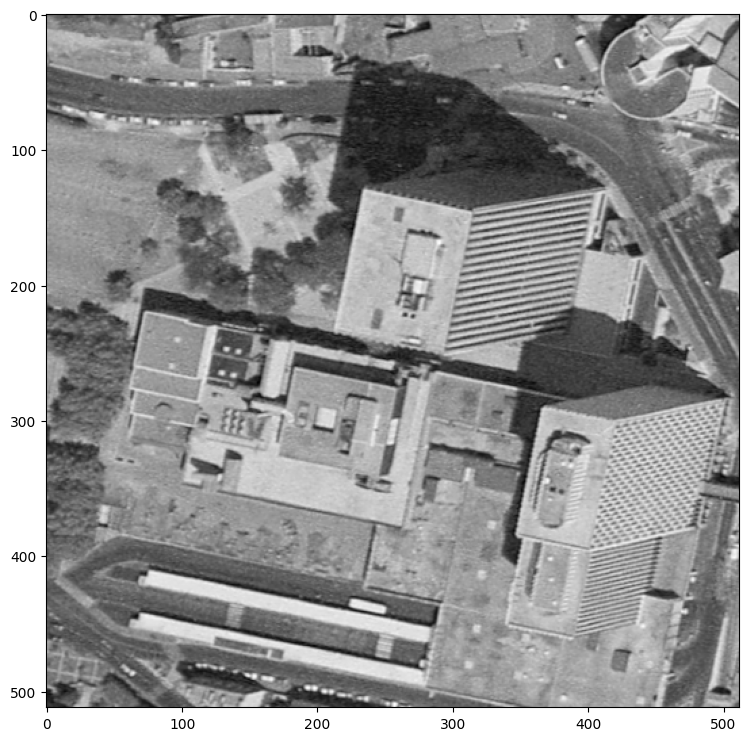

In [6]:
path = "imagesTP1/zebres.tif"
image_rgb = skio.imread(path)
print("rgb image shape : "+str(image_rgb.shape))

plt.rcParams['figure.figsize'] = [9, 9] #control the size of the figure
plt.imshow(image_rgb)
plt.show()

path = "imagesTP1/montreuil.tif"
image_gs = skio.imread(path,as_gray=True) #the default value for as_gray is False
print("gray image shape : "+str(image_gs.shape))

plt.figure(figsize=(9,9))
# plt.rcParams['figure.figsize'] = [9, 9] #control the size of the figure
plt.imshow(image_gs, cmap = "gray")
plt.show()

## Fourier Domain
The Fourier Transform of an image allows us to analyze the frequential content of an image, by going from the spatial domain to the frequential domain.
To compute the 2D Fourier transform of a grayscale image, we will use the fft2() function of the numpy.fft library.

To display the Fourier transform centered on the (0,0) component, we will use
the fft.fftshift() to the Fourier transform.

In [7]:
# load the image and compute the fft
#Fourier transform converts images from pixels to patterns, textures, repeating structures(Frequency domain)
#Instead of what color is each pixel, its what patterns make up this image.
#low frequencies = smooth areas
#High frequencies = edges, sharp details
img = skio.imread("imagesTP1/montreuil.tif")
image_fft = fft.fftshift(fft.fft2(img))

Let's visualize the modulus of the Fourier transform by applying the log(abs(x)+0.1) to the FFT. (Remember, the Fourier transform is a complex number!)

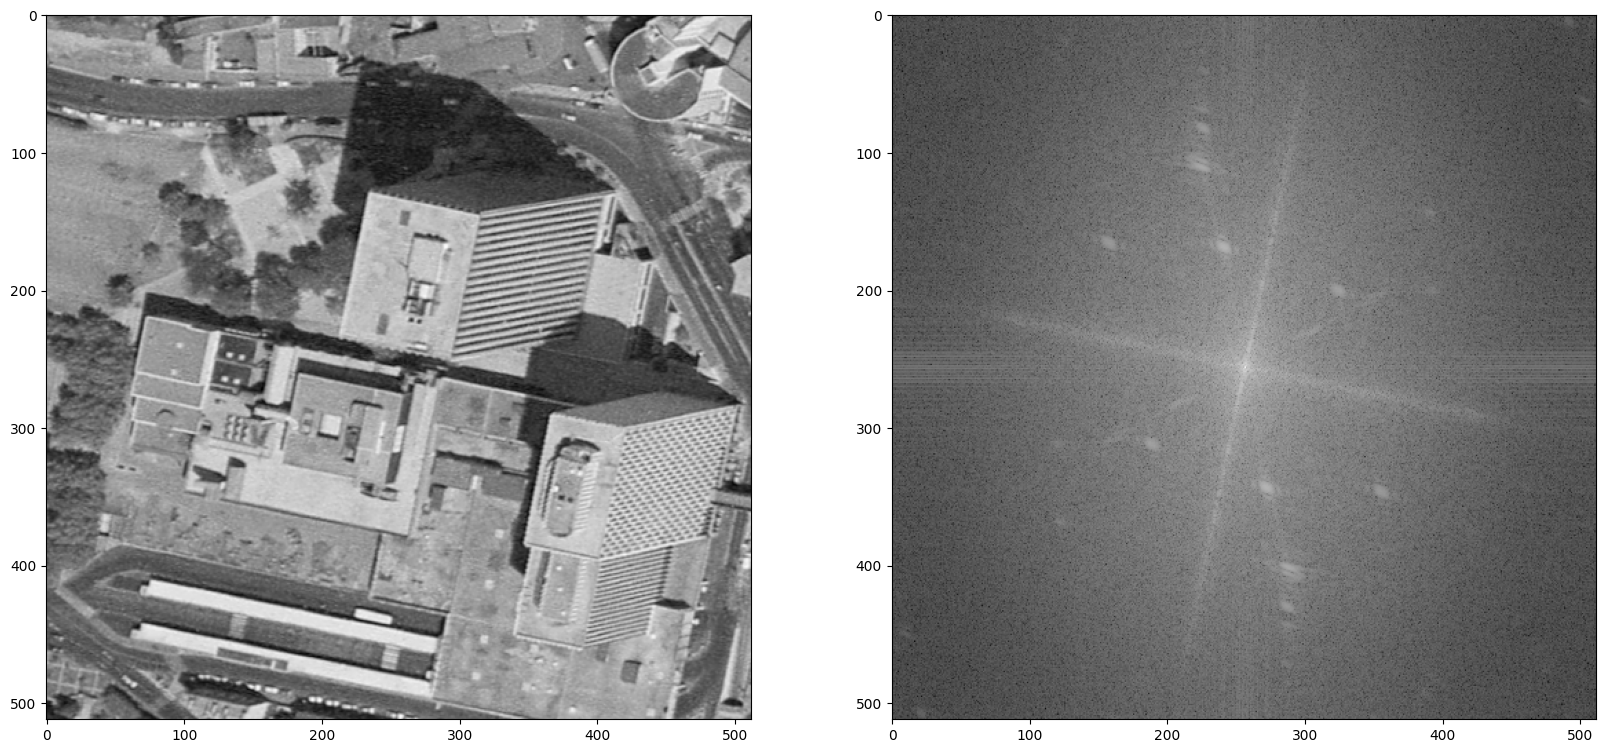

In [10]:
# Visualize the Fourier transform
modfft = np.log(np.abs(image_fft)+0.1)

fig, axs = plt.subplots(1, 2, figsize=(20,20))
axs[0].imshow(img, cmap='gray')
axs[1].imshow(modfft, cmap='gray')
plt.show()

Questions :
- Why is important to visualize the logarithm of the Fourier Transform?
- Explain the lines and peaks in the FFT in relation to the image content.

## Image Sampling

Images can be very large and thus use a lot of memory. It is sometimes needed to reduce images using a sub-sampling technique. However, when done unproperly, the sub-sampled image can present artifacts. Thanks to the Fourier transform, we will understand what is the underlying problem.

In the following cell you should subsample the image by taking one pixel every two pixels in each direction. (The number of pixels is thus divided by 4.)

image shape : (512, 512)
subsampled image shape : (256, 256)


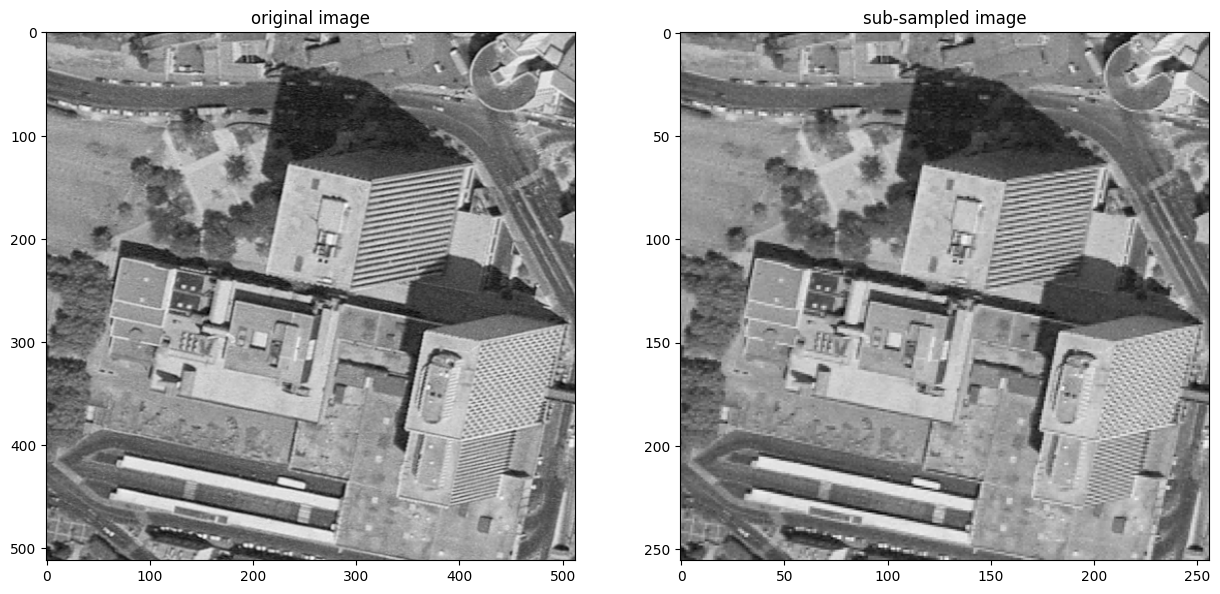

In [14]:
# subsampling the image
img_subsampled = img[::2, ::2] #Only takes every every 2nd pixel on the row and on the column. Row first then column.
print("image shape : "+str(img.shape))
print("subsampled image shape : "+str(img_subsampled.shape))

#visualize the images
fig, axs = plt.subplots(1, 2, figsize=(15,15))
axs[0].imshow(img, cmap='gray')
axs[0].set_title("original image")
axs[1].imshow(img_subsampled, cmap='gray')
axs[1].set_title("sub-sampled image")
plt.show()


- **Q**: Describe the visual artifacts you see in the sub-sampled image
- **A** : The subsampled image looks blocky. This is because by subsampling the image, we reduce the number of pixels available, hence high definition parts of the picture gets erased.

Let's compare the Fourier Transform of the subsampled image to the one of the original image:

In [ ]:
##compute the modulus
modfft_sub = ...

##visualize the two images
fig, axs = plt.subplots(1, 2, figsize=(10,10))
axs[0].imshow(modfft, cmap='gray')
axs[0].set_title("original spectrum")
axs[1].imshow(modfft_sub, cmap='gray')
axs[1].set_title("subsampled image spectrum")
plt.show()

- **Q** : What is the phenomenon we observe ? How can you explain it ?
- **A** : ...

## Low pass Filtering

In order to smooth or to denoise an image, a very simple way is to apply a local mean filtering. In order to do that, we would convolve the image with a uniform kernel :
$$k = \frac{1}{25}\times\mathbb{1}_{(5,5)}$$

$$I_{smooth} = k*I$$

Let's build this filter and observe its Fourier transform, in a larger image. Create a binary image of size (512,512) with the filter at its center, and visualize its Fourier Transform.

**Clue:** The central $5 \times 5$ square in a $512 \times 512$ image corresponds to indices `[253:258,253:258]`.

In [ ]:
kernel_square = (1/25)*np.ones((5,5))
kernel = np.zeros((512,512))
...

kernel_fft = ...

plt.title("Fourier Transform of the Mean Filter")
plt.imshow(kernel_fft, cmap = "gray")
plt.show()

Let's apply this filter to the image using the scipy.signal.convolve2d() function.

In [ ]:
from scipy.signal import convolve2d
# filtered image
img_filtered =  ...

#visualize images
fig, axs = plt.subplots(1, 2, figsize=(15,15))
axs[0].imshow(img, cmap='gray')
axs[0].set_title("original image")
axs[1].imshow(img_filtered, cmap='gray')
axs[1].set_title("filtered image")
plt.show()

- **Q**: What is the aspect of this image ?
- **A**:...


 Let's visualize the FFT of the filtered image.

In [ ]:
##compute the modulus
modfft_f = ...

##visualize the two images
fig, axs = plt.subplots(1, 2, figsize=(15,15))
axs[0].imshow(modfft, cmap='gray')
axs[0].set_title("original spectrum")
axs[1].imshow(modfft_f, cmap='gray')
axs[1].set_title("filtered image spectrum")
plt.show()

To illustrate the interest of low-pass filtering, we will apply it to a "noisy" image.

In the following cell, you will
- add Gaussian noise of standard deviation 50 to `img`
- filter it with the kernel `k` and observe the result.

In [ ]:
std = 50
noisy_image = ...

filtered_image = ...

## display the noisy image, the filtered image and the original image
    #visualize images
fig, axs = plt.subplots(1, 2, figsize=(15,15))
axs[0].imshow(noisy_image, cmap='gray')
axs[0].set_title("original image")
axs[1].imshow(filtered_image, cmap='gray')
axs[1].set_title("filtered image")
plt.show()

**Q :** Does this low pass filtering reduce the influence of the noise? Could you think of another kernel?

**A :**

In the following cell, you will reduce the image `img` but after having filtered it with `k`.

In [ ]:
### Your time to code!
...

fig, axs = plt.subplots(1, 2, figsize=(15,15))
axs[0].imshow(img_subsampled, cmap='gray')
axs[0].set_title("subsampled image")
axs[1].imshow(filtered_image_subsampled, cmap='gray')
axs[1].set_title("subsampled filtered image")
plt.show()

## (Bonus) Contour detection with Prewitt filtering

A simple way to detect contours in images is to apply a high pass filter to our image. In this section we will implement a simple Prewitt filter.

The Prewitt filter convolves the kernel  $K = \begin{pmatrix}
-1 & 0 & 1\\
-1 & 0 & 1 \\
-1 & 0 & 1 \\
\end{pmatrix} $ to the image for the horizontal filtering, and its transpose for the vertical filtering. The filtering formula is the following :  $$ y = \frac{1}{2}(K*x + K^T*x).$$
Let's implement this filter and visualize its results.

In [ ]:

kernel = ...
img_filtered_hor = ...
img_filtered_ver = ...
img_filtered = ...

filtered_img = prewitt_filtering(img)

plt.imshow(filtered_img, cmap = "gray")
plt.show()